# Assignment 1 Perceptron Image Classification
### Arseniy Uspenskiy
### USPARS001

Import necessary packages

In [46]:
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import itertools

## Data Processing

Creating method for loading all images of a specified directory

Images are flattened into vectors and returned alongside their character label

In [47]:
CHARACTERS = ["bart_simpson", "charles_montgomery_burns", "homer_simpson",
    "krusty_the_clown", "lisa_simpson", "marge_simpson",
    "milhouse_van_houten", "moe_szyslak", "ned_flanders", "principal_skinner"]

# Method for loading images from a particular directory e.g.(rgb-train)
def load_dataset(path : str):

    vectors = []
    labels = []

    for name in CHARACTERS:
        char_dir = os.path.join(path, name)

        for file in os.listdir(char_dir):

            img_path = os.path.join(char_dir, file)
            img = Image.open(img_path)
            arr = np.array(img)
            vectors.append(arr.flatten())
            labels.append(CHARACTERS.index(name))

    x = np.array(vectors)
    y = np.array(labels)

    return x, y

Loading seperate training, validation, and test datasets for both rgb and grayscale

In [48]:
X_train_gray_full, y_train_gray_full = load_dataset("datasets/grayscale/train")
X_test_gray, y_test_gray = load_dataset("datasets/grayscale/test")

X_train_rgb_full, y_train_rgb_full = load_dataset("datasets/rgb/train")
X_test_rgb, y_test_rgb = load_dataset("datasets/rgb/test")

X_train_gray, X_val_gray, y_train_gray, y_val_gray = train_test_split(X_train_gray_full, y_train_gray_full, test_size=0.2, stratify=y_train_gray_full, random_state=42)
X_train_rgb, X_val_rgb, y_train_rgb, y_val_rgb = train_test_split(X_train_rgb_full, y_train_rgb_full, test_size=0.2, stratify=y_train_rgb_full, random_state=42)

## Multi-class perceptron implementation

BinaryPerceptron with a predict method for outputting 0 or 1

In [49]:

class BinaryPerceptron:

    def __init__(self, id: int, n: int, alpha: float, init: np.array):
        self.id = id
        self.weights = np.ones(n, dtype=float) * init
        self.bias = 0.1
        self.alpha = alpha

    def score(self, x : np.array) -> float:
            weighted_sum = np.dot(x, self.weights) + self.bias
            return weighted_sum

    def predict(self, x : np.array) -> int:
        return 1 if self.score(x) >= 0 else 0

    def learning_rule(self, x, y):
        g = self.predict(x)
        self.weights = self.weights + self.alpha * (y - g) * (x)
        self.bias = self.bias + self.alpha * (y - g)

    def __repr__(self):
        return CHARACTERS[self.id] + " Perceptron"

MultiClassPerceptron which utilizes a one versus rest approach using 10 binary perceptrons to classify images

Uses Z-score normalization

In [50]:
class MultiClassPerceptron:

    def __init__(self, n: int, alpha: float, init: float):
        self.perceptrons = [BinaryPerceptron(i, n, alpha, init) for i in range(10)]

    def predict(self, x) -> float:
        top_score = float("-inf")
        top_num = 0
        for i in range(len(self.perceptrons)):
            y = self.perceptrons[i].score(x)
            if y > top_score:
                top_score = y
                top_num = i

        return top_num

    def train_perceptron(self, X : np.array, y : np.array):
        for i in range(len(X)):
            for percep in self.perceptrons:
                y_converted = 0
                if percep.id == y[i]:
                    y_converted = 1
                percep.learning_rule(X[i], y_converted)


## Training

Method for assesing accuracy of a perceptron

In [51]:
def accuracy(perceptron: MultiClassPerceptron, data_X : np.array, data_y : np.array) -> float:
    correct = 0
    total = 0

    for X, y in zip(data_X, data_y):
        y_hat = perceptron.predict(X)
        if y_hat == y:
            correct += 1
        total += 1

    accuracy = correct / total
    return accuracy

Method for training Perceptron over multiple epochs

Exit Conditions: max epochs reached or insignificant improvements in accuracy

In [52]:
def test_perceptron(alpha: float, init: CustomFunction, norm: CustomFunction, min_delta=0.0001, patience=5, seed=25):
    p_gray = MultiClassPerceptron(len(X_train_gray[0]), alpha, init(X_train_gray))
    p_rgb = MultiClassPerceptron(len(X_train_rgb[0]), alpha, init(X_train_rgb))
    epochs = 30
    x_gray = []
    y_gray = []
    x_rgb = []
    y_rgb = []

    best_acc_gray, best_acc_rgb = 0.0, 0.0
    no_improve_gray, no_improve_rgb = 0, 0
    stopped_gray, stopped_rgb = False, False
    stop_epoch_gray, stop_epoch_rgb = epochs, epochs

    rng = np.random.default_rng(seed)

    for epoch in range(epochs):

        perm = rng.permutation(len(X_train_gray))
        X_train_gray_shuff = norm(X_train_gray[perm])
        y_train_gray_shuff = y_train_gray[perm]
        X_train_rgb_shuff = norm(X_train_rgb[perm])
        y_train_rgb_shuff = y_train_rgb[perm]

        X_val_gray_norm = norm(X_val_gray)
        X_val_rgb_norm = norm(X_val_rgb)

        if not stopped_gray:
            p_gray.train_perceptron(X_train_gray_shuff, y_train_gray_shuff)
            acc_gray = accuracy(p_gray, X_val_gray_norm, y_val_gray)
            x_gray.append(epoch + 1)
            y_gray.append(acc_gray)

            if acc_gray - best_acc_gray > min_delta:
                best_acc_gray = acc_gray
                no_improve_gray = 0
            else:
                no_improve_gray += 1

            if no_improve_gray >= patience:
                stopped_gray = True
                stop_epoch_gray = epoch + 1

        if not stopped_rgb:
            p_rgb.train_perceptron(X_train_rgb_shuff, y_train_rgb_shuff)     
            acc_rgb = accuracy(p_rgb, X_val_rgb_norm, y_val_rgb)
            x_rgb.append(epoch+1)
            y_rgb.append(acc_rgb)

            if acc_rgb - best_acc_rgb > min_delta:
                best_acc_rgb = acc_rgb
                no_improve_rgb = 0
            else:
                no_improve_rgb += 1
            
            if no_improve_rgb >= patience:
                stopped_rgb = True
                stop_epoch_rgb = epoch + 1

        if stopped_gray and stopped_rgb:
            break

    text_gray = f"Final accuracy gray: {acc_gray}, a: {alpha}, init: {init}, norm: {norm}"
    text_rgb = f"Final accuracy rgb: {acc_rgb}, a: {alpha}, init: {init}, norm: {norm}"
    params = [alpha, init, norm]

    print(text_gray)
    print(text_rgb)
    print()

    return acc_gray, acc_rgb, x_gray, x_rgb, y_gray, y_rgb, stop_epoch_gray, stop_epoch_rgb, text_gray, text_rgb, params, params, p_gray, p_rgb

Class for better utilization of functions

In [53]:
class CustomFunction:
    def __init__(self, func, custom_message):
        self.func = func
        self.custom_message = custom_message

    def __call__(self, *args, **kwargs):
        return self.func(*args, **kwargs)

    def __repr__(self):
        return self.custom_message

Functions for data initialization

In [54]:
def uniform(X: np.array) -> np.array:
    return np.random.uniform(low=-0.01, high=0.01, size=(len(X[0])))

cust_uniform = CustomFunction(uniform, "Uniform")

def guassian(X: np.array) -> np.array:
    return np.random.normal(loc=0.0, scale=0.01, size=len(X[0]))

cust_guassian = CustomFunction(guassian, "Guassian")

def zeros(X: np.array) -> np.array:
    return np.zeros(len(X[0]))

cust_zeros = CustomFunction(zeros, "Zero")

Functions for data normalization/standardization

In [55]:
def normalize(X : np.array) -> np.array:
    return X / 255.0

cust_normalize = CustomFunction(normalize, "Normalize")

def standardize(X : np.array) -> np.array:
    standardized_X = []
    mean = np.mean(X)
    std = np.std(X)
    for elem in X:
        standardized_X.append((elem - mean) / std)

    return np.array(standardized_X)

cust_standardize = CustomFunction(standardize, "Standardize")

def default(X: np.array) -> np.array:
    return X

cust_default = CustomFunction(default, "None")

Plotting Learning Data

In [56]:

def show_graph(X: np.array, y: np.array):
    plt.plot(X, y, marker='o')
    plt.xlim(0, 30)
    plt.ylim(0, 0.60) 
    plt.show()

Loop for Testing Perceptrons on different combinations of alpha values and normalization methods 

Final accuracy gray: 0.20625, a: 0.5, init: Zero, norm: None
Final accuracy rgb: 0.34875, a: 0.5, init: Zero, norm: None

Final accuracy gray: 0.20625, a: 0.5, init: Zero, norm: Normalize
Final accuracy rgb: 0.3975, a: 0.5, init: Zero, norm: Normalize

Final accuracy gray: 0.21625, a: 0.5, init: Zero, norm: Standardize
Final accuracy rgb: 0.368125, a: 0.5, init: Zero, norm: Standardize

Final accuracy gray: 0.1875, a: 0.5, init: Uniform, norm: None
Final accuracy rgb: 0.326875, a: 0.5, init: Uniform, norm: None

Final accuracy gray: 0.21125, a: 0.5, init: Uniform, norm: Normalize
Final accuracy rgb: 0.3825, a: 0.5, init: Uniform, norm: Normalize

Final accuracy gray: 0.195625, a: 0.5, init: Uniform, norm: Standardize
Final accuracy rgb: 0.378125, a: 0.5, init: Uniform, norm: Standardize

Final accuracy gray: 0.2075, a: 0.5, init: Guassian, norm: None
Final accuracy rgb: 0.345625, a: 0.5, init: Guassian, norm: None

Final accuracy gray: 0.16625, a: 0.5, init: Guassian, norm: Normalize
F

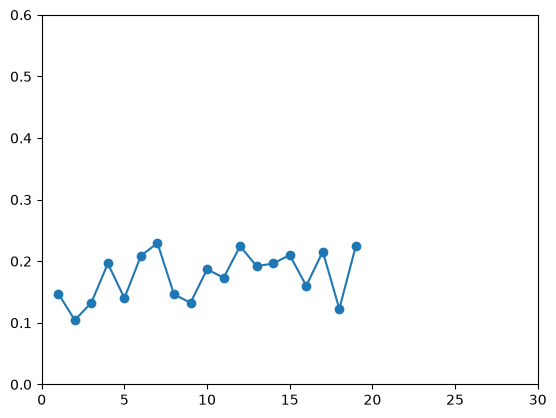

RGB Graph Stop Epoch: 30
Final accuracy rgb: 0.42125, a: 0.05, init: Uniform, norm: Normalize


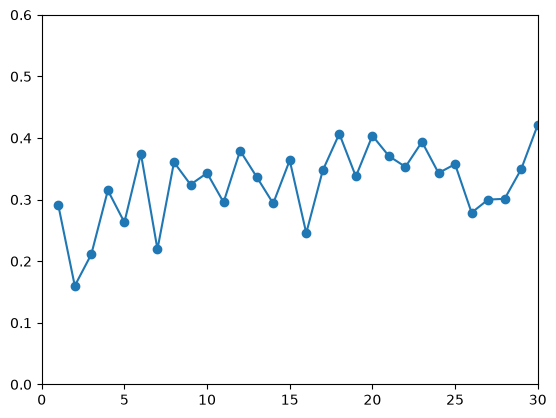

In [57]:
alphas = [0.5, 0.1, 0.05, 0.01, 0.005]
inits = [cust_zeros, cust_uniform, cust_guassian]
norms = [cust_default, cust_normalize, cust_standardize]
tests = itertools.product(alphas, inits, norms)

max_rgb = [0]
max_gray = [0]

for test in tests:

    output = test_perceptron(*test, 0.0001, 12)

    if output[0] > max_gray[0]:
        max_gray = output[::2]
    if output[1] > max_rgb[0]:
        max_rgb = output[1::2]

print(f"Gray Graph Stop Epoch: {max_gray[3]}")
print(max_gray[4])
show_graph(max_gray[1], max_gray[2])
print(f"RGB Graph Stop Epoch: {max_rgb[3]}")
print(max_rgb[4])
show_graph(max_rgb[1], max_rgb[2])

Method for evaluating a model

In [58]:
def evaluate(preceptron: MultiClassPerceptron, X_data, y_data):
    y_pred = []

    for i in range(len(X_data)):
        y_pred.append(preceptron.predict(X_data[i]))

    y_pred = np.array(y_pred)

    acc = accuracy_score(y_data, y_pred)
    cm = confusion_matrix(y_data, y_pred, labels=range(len(CHARACTERS)))
    report = classification_report(y_data, y_pred, labels=range(len(CHARACTERS)), target_names=CHARACTERS, zero_division=0)

    print(f"Accuracy: {acc:.3f}\n")
    print(report)

    return acc, cm, report

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CHARACTERS)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

Evaluating two best models

In [ ]:
acc_g, cm_g, report_g = evaluate(output[-2], np.concatenate((X_val_gray, X_test_gray), axis=0), np.concatenate((y_val_gray, y_test_gray), axis=0))
acc_rgb, cm_rgb, report_rgb = evaluate(output[-1], np.concatenate((X_val_rgb, X_test_rgb), axis=0), np.concatenate((y_val_rgb, y_test_rgb), axis=0))

plot_confusion_matrix(cm_g)
plot_confusion_matrix(cm_rgb)

Creating new modified brightness and rotation training sets, and a modified training method

In [62]:
def augment_bright(images, low=0.7, high=1.3, seed=25):
    rng = np.random.default_rng(seed)
    aug_arr = np.empty((len(images), images.shape[1] * images.shape[2] * images.shape[3]), dtype=images.dtype)

    for i in range(len(images)):
        b = rng.uniform(low, high)
        bright = np.clip(images[i].astype(float) * b, 0, 255).astype(np.uint8)
        aug_arr[i] = bright.flatten()

    return aug_arr

def augment_rotation(images, low=-15, high=15, seed=25):
    rng = np.random.default_rng(seed)
    aug_arr = np.empty((len(images), images.shape[1] * images.shape[2] * images.shape[3]), dtype=images.dtype)

    for i in range(len(images)):
        angle = rng.uniform(low, high)
        rotated = Image.fromarray(images[i]).rotate(angle)
        aug_arr[i] = np.array(rotated).flatten()
    
    return aug_arr

side = int(np.sqrt(X_train_rgb.shape[1] // 3))
X_train_rgb_raw = X_train_rgb.reshape(-1, side, side, 3).astype(np.uint8)

X_train_brightness = np.concatenate((X_train_rgb, augment_bright(X_train_rgb_raw)), axis=0)
y_train_brightness = np.concatenate((y_train_rgb, y_train_rgb), axis=0)

X_train_rotation = np.concatenate((X_train_rgb, augment_rotation(X_train_rgb_raw)), axis=0)
y_train_rotation = np.concatenate((y_train_rgb, y_train_rgb), axis=0)

def test_one_perceptron(X_data, y_data, alpha: float, init: CustomFunction, norm: CustomFunction, min_delta=0.0001, patience=5, seed=25):
    p = MultiClassPerceptron(len(X_data[0]), alpha, init(X_data))
    epochs = 30
    x = []
    y = []
    
    best_acc = 0.0
    no_improve = 0
    stopped = False
    stop_epoch = epochs
    
    rng = np.random.default_rng(seed)

    for epoch in range(epochs):
    
        perm = rng.permutation(len(X_data))

        X_train_shuff = norm(X_data[perm])
        y_train_shuff = y_data[perm]
        
        X_val_norm = norm(X_val_rgb)
        
                
        if not stopped:
            p.train_perceptron(X_train_shuff, y_train_shuff)     
            acc = accuracy(p, X_val_norm, y_val_rgb)
            x.append(epoch+1)
            y.append(acc)
    
        if acc - best_acc > min_delta:
            best_acc = acc
            no_improve = 0
        else:
            no_improve += 1
                                
        if no_improve >= patience:
            stopped = True
            stop_epoch = epoch + 1
                    
        if stopped:
            break
                    
    text = f"Final accuracy: {acc}, a: {alpha}, init: {init}, norm: {norm}"
                    
    print(text)
    print()
                    
    return acc, x, y, stop_epoch, text, p

Training on all three unique training sets

In [ ]:
seeds = [5, 12, 17, 20, 32]
output_new = [[], [], []]
data = [[X_train_rgb, y_train_rgb], [X_train_brightness, y_train_brightness], [X_train_rotation, y_train_rotation]]

for i in range(3):
    for s in seeds:
        output_new[i].append(test_one_perceptron(data[i][0], data[i][1], *max_rgb[-2], 0.0001, 5, s))

Showing comparison of values from all three different training sets

In [ ]:
names = ["Original", "Brightness", "Rotation"]
summary = []

for i, name in enumerate(names):
    accuracies = []
    confusions = []

    for run in output_new[i]:
        p = run[-1]

        acc, cm, report = evaluate(p, np.concatenate((X_val_rgb, X_test_rgb), axis=0), np.concatenate((y_val_rgb, y_test_rgb), axis=0))

        accuracies.append(acc)
        confusions.append(cm)

    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)
    mean_cm = np.mean(confusions, axis=0)

    summary.append({"dataset": name, "mean_accuracy": mean_acc, "std_accuracy": std_acc, "mean_confusion_matrix": mean_cm})

    print(f"{name}: {mean_acc:.3f} ± {std_acc:.3f}")